In [84]:
import pandas as pd
import datetime
import joblib


In [66]:
data=pd.read_csv(r"D:\Tejashri\anaconda\anaconda_projects\Ride_ai\rideflow_datasets.csv")

In [67]:
data.head()

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean


In [68]:
data.columns

Index(['ride_id', 'timestamp', 'pickup_zone', 'drop_zone', 'pickup_lat',
       'pickup_long', 'drop_lat', 'drop_long', 'driver_id', 'customer_id',
       'fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating',
       'estimated_eta_min', 'actual_eta_min', 'ride_status', 'traffic_level',
       'weather', 'driver_active', 'feedback_text'],
      dtype='object')

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ride_id            50000 non-null  float64
 1   timestamp          50000 non-null  object 
 2   pickup_zone        50000 non-null  object 
 3   drop_zone          50000 non-null  object 
 4   pickup_lat         50000 non-null  float64
 5   pickup_long        50000 non-null  float64
 6   drop_lat           50000 non-null  float64
 7   drop_long          50000 non-null  float64
 8   driver_id          50000 non-null  float64
 9   customer_id        50000 non-null  float64
 10  fare_price         50000 non-null  float64
 11  surge_multiplier   50000 non-null  float64
 12  driver_rating      50000 non-null  float64
 13  customer_rating    50000 non-null  float64
 14  estimated_eta_min  50000 non-null  float64
 15  actual_eta_min     50000 non-null  float64
 16  ride_status        500

In [70]:
data.isnull().sum()


ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64

In [71]:
data.isnull().sum().sum()

np.int64(0)

In [72]:
print("=== Empty Strings Check ===")
print((data == '').sum())

=== Empty Strings Check ===
ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64


In [73]:
print("\n=== 'Unknown' / 'N/A' string check ===")
print((data == 'unknown').sum())
print((data == 'N/A').sum())


=== 'Unknown' / 'N/A' string check ===
ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feedback_text        0
dtype: int64
ride_id              0
timestamp            0
pickup_zone          0
drop_zone            0
pickup_lat           0
pickup_long          0
drop_lat             0
drop_long            0
driver_id            0
customer_id          0
fare_price           0
surge_multiplier     0
driver_rating        0
customer_rating      0
estimated_eta_min    0
actual_eta_min       0
ride_status          0
traffic_level        0
weather              0
driver_active        0
feed

In [74]:
data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')

In [75]:
data['year'] = data['timestamp'].dt.year
data['month'] = data['timestamp'].dt.month
data['day'] = data['timestamp'].dt.day
data['hour'] = data['timestamp'].dt.hour
data['minute'] = data['timestamp'].dt.minute
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ride_id            50000 non-null  float64       
 1   timestamp          50000 non-null  datetime64[ns]
 2   pickup_zone        50000 non-null  object        
 3   drop_zone          50000 non-null  object        
 4   pickup_lat         50000 non-null  float64       
 5   pickup_long        50000 non-null  float64       
 6   drop_lat           50000 non-null  float64       
 7   drop_long          50000 non-null  float64       
 8   driver_id          50000 non-null  float64       
 9   customer_id        50000 non-null  float64       
 10  fare_price         50000 non-null  float64       
 11  surge_multiplier   50000 non-null  float64       
 12  driver_rating      50000 non-null  float64       
 13  customer_rating    50000 non-null  float64       
 14  estima

In [77]:
data.columns

Index(['ride_id', 'timestamp', 'pickup_zone', 'drop_zone', 'pickup_lat',
       'pickup_long', 'drop_lat', 'drop_long', 'driver_id', 'customer_id',
       'fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating',
       'estimated_eta_min', 'actual_eta_min', 'ride_status', 'traffic_level',
       'weather', 'driver_active', 'feedback_text', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'is_weekend'],
      dtype='object')

In [78]:
# Check how traffic and weather impact the average surge and fare
pivot_table = data.groupby(['traffic_level', 'weather'])[['surge_multiplier', 'fare_price']].mean()
print(pivot_table)

#High traffic and clear weather show the highest surge (~1.45), suggesting a "busy hour" effect.

                       surge_multiplier  fare_price
traffic_level weather                              
high          clear            1.452937  289.140429
              cloudy           1.394888  285.017181
              rain             1.393072  285.587318
low           clear            1.383900  281.338985
              cloudy           1.396668  296.051093
              rain             1.386171  287.853188
medium        clear            1.399947  298.809132
              cloudy           1.347774  297.178802
              rain             1.427306  292.505493


In [79]:
# Find the top 3 busiest pickup zones
print(data['pickup_zone'].value_counts().head(3))

# See when the rush hours are
print(data.groupby('hour')['ride_id'].count())

#T Nagar and Anna Nagar are your "hotspots." The demand is relatively flat across 24 hours (around 2k rides/hour)

pickup_zone
T Nagar       7786
Anna Nagar    7728
Tambaram      7462
Name: count, dtype: int64
hour
0     2103
1     2184
2     2117
3     2258
4     2189
5     2251
6     2218
7     2199
8     2190
9     2155
10    1986
11    2031
12    2003
13    1976
14    1972
15    1932
16    2021
17    1993
18    1975
19    2102
20    2088
21    2053
22    1990
23    2014
Name: ride_id, dtype: int64


In [80]:
# Calculate the difference between actual and estimated ETA
data['eta_error'] = data['actual_eta_min'] - data['estimated_eta_min']
print(data[['eta_error']].describe())
#On average, rides are taking 2.78 minutes longer than estimated

          eta_error
count  50000.000000
mean       2.786988
std        7.902630
min      -16.920674
25%       -2.770548
50%        3.010454
75%        8.553503
max       22.278287


In [81]:
coords = data[['pickup_lat', 'pickup_long']]

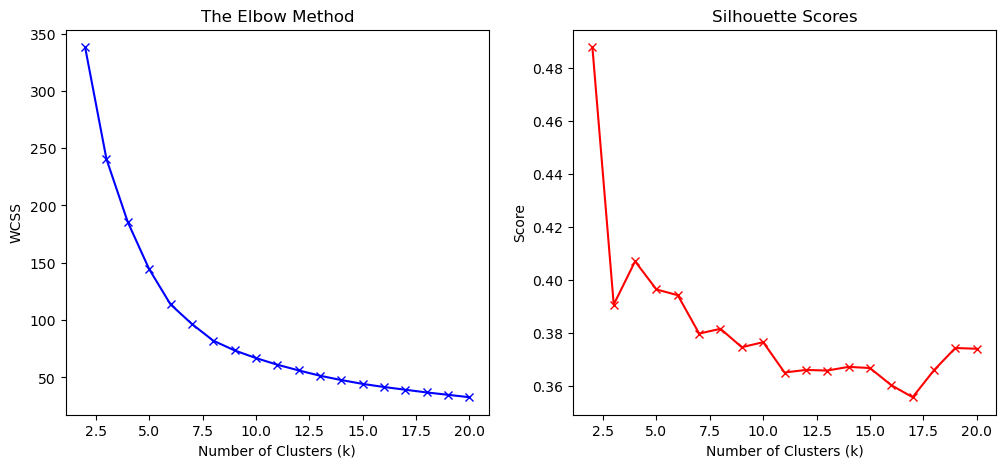

In [82]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


wcss = []
silhouette_avg = []
k_range = range(2, 21)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(coords)
    
    wcss.append(kmeans.inertia_)
    
    sample_idx = data.sample(5000, random_state=42).index
    score = silhouette_score(coords.loc[sample_idx], kmeans.labels_[sample_idx])
    silhouette_avg.append(score)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bx-')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'rx-')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.show()

In [89]:
# Choose your optimal k from the elbow/silhouette plots
k = 5  # replace with your chosen k

kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=10)
data['pickup_cluster'] = kmeans_final.fit_predict(coords)

print(data['pickup_cluster'].value_counts())
data.head()

pickup_cluster
3    13674
4    10467
0    10343
2     8303
1     7213
Name: count, dtype: int64


,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,feedback_text,year,month,day,hour,minute,day_of_week,is_weekend,eta_error,pickup_cluster
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,Driver was polite,2025,1,2,1,30,3,0,6.526752,3
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,Driver cancelled suddenly,2025,1,5,12,45,6,1,8.913067,4
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,Driver cancelled suddenly,2025,1,9,23,0,3,0,-7.163014,3
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,Good experience,2025,1,3,19,30,4,0,-11.176139,4
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,Vehicle was not clean,2025,1,2,2,30,3,0,1.317745,2


In [90]:
joblib.dump(kmeans_final, 'geospatial_cluster_model.pkl')
print("✅ cluster Saved as 'geospatial_cluster_model.pkl'")

✅ cluster Saved as 'geospatial_cluster_model.pkl'


In [91]:
data.to_csv('RideFlow_Processed_Data.csv', index=False)